In [1]:
import pandas as pd

df = pd.read_csv(r"D:\02 SEMESTER\ML\Project\2016.csv")
print(df.shape)
print(df.dtypes)
print(df.head(2))

(175331, 31)
event_id_cnty          object
event_date             object
year                    int64
time_precision          int64
disorder_type          object
event_type             object
sub_event_type         object
actor1                 object
assoc_actor_1          object
inter1                 object
actor2                 object
assoc_actor_2          object
inter2                 object
interaction            object
civilian_targeting     object
iso                     int64
region                 object
country                object
admin1                 object
admin2                 object
admin3                 object
location               object
latitude              float64
longitude             float64
geo_precision           int64
source                 object
source_scale           object
notes                  object
fatalities              int64
tags                   object
timestamp               int64
dtype: object
  event_id_cnty  event_date  year  time_pre

In [2]:

# Parse date properly using event_date not timestamp
df['date'] = pd.to_datetime(df['event_date'])

# Basic exploration
print("=== Year-wise counts ===")
print(df.groupby('year').size())

print("\n=== Event types ===")
print(df['event_type'].value_counts())

print("\n=== Sub-event types ===")
print(df['sub_event_type'].value_counts())

print("\n=== Disorder types ===")
print(df['disorder_type'].value_counts())

print("\n=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== Top 10 districts ===")
print(df['admin2'].value_counts().head(10))

print("\n=== Top 15 actors ===")
print(df['actor1'].value_counts().head(15))

print("\n=== Fatalities ===")
print(df['fatalities'].describe())

=== Year-wise counts ===
year
2016    10818
2017    11251
2018    14595
2019    18997
2020    16999
2021    25851
2022    21982
2023    24191
2024    26727
2025     3920
dtype: int64

=== Event types ===
event_type
Protests    175331
Name: count, dtype: int64

=== Sub-event types ===
sub_event_type
Peaceful protest                      165254
Protest with intervention               9525
Excessive force against protesters       552
Name: count, dtype: int64

=== Disorder types ===
disorder_type
Demonstrations                        174779
Political violence; Demonstrations       552
Name: count, dtype: int64

=== Missing values ===
assoc_actor_1          40395
actor2                164877
assoc_actor_2         174221
inter2                164877
civilian_targeting    174779
admin2                    95
admin3                  2906
tags                   33243
dtype: int64

=== Top 10 districts ===
admin2
Jammu          5479
Yinmarbin      3798
Ludhiana       2660
New Delhi      2339
Cha

In [12]:
print(df.groupby(df['date'].dt.year).size())

date
2019     8004
2020     2140
2021    10862
2022    27423
2023    23532
2024    47589
2025    55675
2026      106
dtype: int64


In [3]:
df_india = df[df['country'] == 'India'].copy()
print(df_india.shape)
print(df_india.groupby('year').size())

(135246, 32)
year
2016     9721
2017    10146
2018    12864
2019    16561
2020    13995
2021    15062
2022    14626
2023    17923
2024    21456
2025     2892
dtype: int64


In [6]:
# Use 'year' column already in data and extract month fresh
df_india = df_india.copy()
df_india['month'] = pd.to_datetime(df_india['event_date']).dt.month

# Monthly counts
df_clean = df_india[df_india['year'] < 2025]
monthly = df_clean.groupby(['year', 'month']).size().reset_index(name='count')

# Average protests by month across all years
avg_by_month = monthly.groupby('month')['count'].mean()
print("=== Average protests by month (across all years) ===")
print(avg_by_month)

# Weekly pattern
print("\n=== Average protests by day of week ===")
dow = pd.to_datetime(df_clean['event_date']).dt.dayofweek
print(df_clean.groupby(dow).size().rename(
    index={0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
))

# Top 10 states
print("\n=== Top 10 states ===")
print(df_india['admin1'].value_counts().head(10))

# Sub event breakdown
print("\n=== Sub-event types ===")
print(df_india['sub_event_type'].value_counts())

=== Average protests by month (across all years) ===
month
1     1218.333333
2     1269.111111
3     1151.444444
4      905.111111
5      947.888889
6     1289.111111
7     1321.555556
8     1387.000000
9     1472.111111
10    1276.777778
11    1102.333333
12    1365.222222
Name: count, dtype: float64

=== Average protests by day of week ===
event_date
Mon    25370
Tue    20428
Wed    19633
Thu    19020
Fri    19940
Sat    15401
Sun    12562
dtype: int64

=== Top 10 states ===
admin1
Punjab               16080
Jammu and Kashmir    15272
Tamil Nadu           11616
Assam                 8181
Uttar Pradesh         7550
Karnataka             6718
Haryana               5983
West Bengal           5648
Telangana             5644
Manipur               5220
Name: count, dtype: int64

=== Sub-event types ===
sub_event_type
Peaceful protest                      127120
Protest with intervention               7901
Excessive force against protesters       225
Name: count, dtype: int64


In [7]:
# State level monthly averages
state_monthly = df_clean.groupby(['admin1', 'year', 'month']).size().reset_index(name='count')

# Average by state and month
state_avg = state_monthly.groupby(['admin1', 'month'])['count'].mean().reset_index()

# Pivot to see state x month matrix
pivot = state_avg.pivot(index='admin1', columns='month', values='count')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print("=== State x Month average protest counts ===")
print(pivot.round(1))

# Which states have highest seasonal variation?
pivot['max_min_ratio'] = pivot.max(axis=1) / pivot.min(axis=1)
print("\n=== States with strongest seasonality (max/min ratio) ===")
print(pivot['max_min_ratio'].sort_values(ascending=False).head(15))

# Which states have highest overall activity?
pivot['mean'] = pivot[['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']].mean(axis=1)
print("\n=== States by average monthly activity ===")
print(pivot['mean'].sort_values(ascending=False).head(15))

=== State x Month average protest counts ===
                                            Jan    Feb    Mar    Apr    May  \
admin1                                                                        
Andaman and Nicobar Islands                 2.8    8.7    5.2    4.6    7.4   
Andhra Pradesh                             45.1   48.8   38.7   31.3   34.4   
Arunachal Pradesh                           5.2    5.2    5.0    4.1    5.1   
Assam                                      92.0   96.8   77.0   35.7   51.3   
Bihar                                      22.8   18.0   21.3   11.4   11.8   
Chandigarh                                 21.1   22.1   20.0   15.1   16.1   
Chhattisgarh                                4.9   13.2   15.5    7.0   10.0   
Dadra and Nagar Haveli and Daman and Diu    NaN    1.0    NaN    1.0    NaN   
Delhi                                      43.0   42.3   35.7   29.0   24.4   
Goa                                         7.6    7.0    7.0    5.5    7.1   
Gujarat

In [8]:
# Check year-on-year trend within states
# to see if we need to detrend before modeling
yearly_state = df_clean.groupby(['admin1', 'year']).size().reset_index(name='count')

# Pick 4 interesting states
for state in ['Punjab', 'Uttar Pradesh', 'Karnataka', 'Assam']:
    data = yearly_state[yearly_state['admin1'] == state]
    print(f"\n{state}:")
    print(data[['year','count']].to_string(index=False))


Punjab:
 year  count
 2016   1953
 2017   1375
 2018   2055
 2019   1863
 2020   1599
 2021   2163
 2022   1597
 2023   1549
 2024   1726

Uttar Pradesh:
 year  count
 2016    525
 2017    622
 2018    409
 2019    785
 2020    616
 2021    543
 2022    746
 2023   1315
 2024   1764

Karnataka:
 year  count
 2016    504
 2017    445
 2018    466
 2019    732
 2020    519
 2021    656
 2022    548
 2023   1151
 2024   1537

Assam:
 year  count
 2016    388
 2017    813
 2018    814
 2019   1603
 2020   1452
 2021    869
 2022    482
 2023    509
 2024   1072


In [9]:
# Build state-month panel
panel = df_clean.groupby(['admin1', 'year', 'month']).size().reset_index(name='count')

# Sort for lag creation
panel = panel.sort_values(['admin1', 'year', 'month']).reset_index(drop=True)

# Previous month count
panel['prev_month_count'] = panel.groupby('admin1')['count'].shift(1)

# Same month previous year
panel['prev_year_same_month'] = panel.groupby(['admin1', 'month'])['count'].shift(1)

# Drop rows where lags are missing
panel_clean = panel.dropna().reset_index(drop=True)

print(panel_clean.shape)
print(panel_clean.head(10))
print(panel_clean.describe())

(2977, 6)
                        admin1  year  month  count  prev_month_count  \
0  Andaman and Nicobar Islands  2018      1      5               1.0   
1  Andaman and Nicobar Islands  2018      4      4               7.0   
2  Andaman and Nicobar Islands  2019      1      2               8.0   
3  Andaman and Nicobar Islands  2019      2     11               2.0   
4  Andaman and Nicobar Islands  2019      3      3              11.0   
5  Andaman and Nicobar Islands  2019      4      4               3.0   
6  Andaman and Nicobar Islands  2019      5      2               4.0   
7  Andaman and Nicobar Islands  2019      6      6               2.0   
8  Andaman and Nicobar Islands  2019      7     11               6.0   
9  Andaman and Nicobar Islands  2019      8      5              11.0   

   prev_year_same_month  
0                   2.0  
1                   1.0  
2                   5.0  
3                   7.0  
4                   7.0  
5                   4.0  
6              

In [10]:
import numpy as np
from itertools import product

# Create complete grid of all state-year-month combinations
states = panel['admin1'].unique()
years = range(2016, 2025)
months = range(1, 13)

# Full grid
full_grid = pd.DataFrame(
    list(product(states, years, months)),
    columns=['admin1', 'year', 'month']
)

# Merge with actual counts, fill missing with 0
panel_full = full_grid.merge(
    df_clean.groupby(['admin1', 'year', 'month']).size().reset_index(name='count'),
    on=['admin1', 'year', 'month'],
    how='left'
).fillna(0)

# Sort for lag creation
panel_full = panel_full.sort_values(['admin1', 'year', 'month']).reset_index(drop=True)

# Recreate lags on complete panel
panel_full['prev_month_count'] = panel_full.groupby('admin1')['count'].shift(1)
panel_full['prev_year_same_month'] = panel_full.groupby(['admin1', 'month'])['count'].shift(1)

# Drop first year since lags will be missing
panel_full = panel_full[panel_full['year'] > 2016].dropna().reset_index(drop=True)

print(panel_full.shape)
print(panel_full[panel_full['admin1'] == 'Andaman and Nicobar Islands'].head(15))

(3456, 6)
                         admin1  year  month  count  prev_month_count  \
0   Andaman and Nicobar Islands  2017      1    2.0               0.0   
1   Andaman and Nicobar Islands  2017      2    0.0               2.0   
2   Andaman and Nicobar Islands  2017      3    0.0               0.0   
3   Andaman and Nicobar Islands  2017      4    1.0               0.0   
4   Andaman and Nicobar Islands  2017      5    0.0               1.0   
5   Andaman and Nicobar Islands  2017      6    0.0               0.0   
6   Andaman and Nicobar Islands  2017      7    0.0               0.0   
7   Andaman and Nicobar Islands  2017      8    0.0               0.0   
8   Andaman and Nicobar Islands  2017      9    0.0               0.0   
9   Andaman and Nicobar Islands  2017     10    0.0               0.0   
10  Andaman and Nicobar Islands  2017     11    0.0               0.0   
11  Andaman and Nicobar Islands  2017     12    0.0               0.0   
12  Andaman and Nicobar Islands  2018    

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Encode state as numeric
le = LabelEncoder()
panel_full['state_encoded'] = le.fit_transform(panel_full['admin1'])

# Features and target
features = ['state_encoded', 'year', 'month', 'prev_month_count', 'prev_year_same_month']
target = 'count'

X = panel_full[features]
y = panel_full[target]

# Split — use last 2 years as test (temporal split, not random)
train = panel_full[panel_full['year'] < 2023]
test = panel_full[panel_full['year'] >= 2023]

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Linear Regression ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.3f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"R2: {r2_score(y_test, y_pred_rf):.3f}")

# Feature importance
print("\n=== Feature Importance (Random Forest) ===")
for feat, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

Train size: 2592, Test size: 864

=== Linear Regression ===
MAE: 19.12
R2: 0.623

=== Random Forest ===
MAE: 19.68
R2: 0.606

=== Feature Importance (Random Forest) ===
prev_month_count: 0.746
prev_year_same_month: 0.121
state_encoded: 0.051
month: 0.049
year: 0.033


In [12]:
# Performance by state activity level
state_means = panel_full.groupby('admin1')['count'].mean()
high_states = state_means[state_means > 50].index
low_states = state_means[state_means <= 50].index

test_high = test[test['admin1'].isin(high_states)]
test_low = test[test['admin1'].isin(low_states)]

for label, subset in [('High activity states', test_high), 
                       ('Low activity states', test_low)]:
    pred = rf.predict(subset[features])
    print(f"\n{label} (n={len(subset)}):")
    print(f"MAE: {mean_absolute_error(subset[target], pred):.2f}")
    print(f"R2: {r2_score(subset[target], pred):.3f}")

# Also check residuals — are errors systematic by month?
test_copy = test.copy()
test_copy['predicted'] = rf.predict(test[features])
test_copy['residual'] = test_copy['count'] - test_copy['predicted']

print("\n=== Average residual by month ===")
print(test_copy.groupby('month')['residual'].mean().round(2))


High activity states (n=240):
MAE: 37.60
R2: 0.178

Low activity states (n=624):
MAE: 12.79
R2: 0.452

=== Average residual by month ===
month
1      1.86
2      7.39
3      4.77
4     -8.12
5     -1.07
6      9.79
7      2.07
8     12.24
9      1.53
10     3.69
11    -3.90
12     9.97
Name: residual, dtype: float64


In [13]:
# Feature 1: State-specific seasonal deviation
# For each state-month, what is the historical average?
state_month_avg = train.groupby(['admin1', 'month'])['count'].mean().reset_index()
state_month_avg.columns = ['admin1', 'month', 'state_month_avg']

panel_v2 = panel_full.merge(state_month_avg, on=['admin1', 'month'], how='left')

# Feature 2: How much did same month last year deviate from state average?
state_avg = train.groupby('admin1')['count'].mean().reset_index()
state_avg.columns = ['admin1', 'state_avg']

panel_v2 = panel_v2.merge(state_avg, on='admin1', how='left')

# Feature 3: Momentum — is activity accelerating or decelerating?
panel_v2['momentum'] = panel_v2['prev_month_count'] - panel_v2.groupby('admin1')['count'].shift(2)

# Feature 4: Month of year as cyclical features (captures that Dec and Jan are close)
panel_v2['month_sin'] = np.sin(2 * np.pi * panel_v2['month'] / 12)
panel_v2['month_cos'] = np.cos(2 * np.pi * panel_v2['month'] / 12)

print(panel_v2.columns.tolist())
print(panel_v2.shape)

['admin1', 'year', 'month', 'count', 'prev_month_count', 'prev_year_same_month', 'state_encoded', 'state_month_avg', 'state_avg', 'momentum', 'month_sin', 'month_cos']
(3456, 12)


In [14]:
# Major elections 2016-2024
elections = [
    # Lok Sabha
    ('National', 2019, 5), ('National', 2024, 5),
    # State elections (state, year, month)
    ('Uttar Pradesh', 2017, 3), ('Uttar Pradesh', 2022, 3),
    ('Punjab', 2017, 2), ('Punjab', 2022, 2),
    ('Assam', 2016, 4), ('Assam', 2021, 4),
    ('West Bengal', 2016, 4), ('West Bengal', 2021, 4),
    ('Tamil Nadu', 2016, 5), ('Tamil Nadu', 2021, 4),
    ('Karnataka', 2018, 5), ('Karnataka', 2023, 5),
    ('Bihar', 2020, 11),
    ('Rajasthan', 2018, 12), ('Rajasthan', 2023, 12),
    ('Madhya Pradesh', 2018, 11), ('Madhya Pradesh', 2023, 11),
    ('Delhi', 2020, 2),
    ('Haryana', 2019, 10), ('Haryana', 2024, 10),
    ('Telangana', 2018, 12), ('Telangana', 2023, 11),
    ('Himachal Pradesh', 2017, 11), ('Himachal Pradesh', 2022, 11),
    ('Gujarat', 2017, 12), ('Gujarat', 2022, 12),
    ('Odisha', 2019, 5), ('Odisha', 2024, 5),
    ('Jharkhand', 2019, 12), ('Jharkhand', 2024, 11),
    ('Kerala', 2016, 5), ('Kerala', 2021, 4),
    ('Manipur', 2017, 3), ('Manipur', 2022, 3),
    ('Uttarakhand', 2017, 2), ('Uttarakhand', 2022, 2),
    ('Goa', 2017, 2), ('Goa', 2022, 2),
]

# Convert to dataframe
elections_df = pd.DataFrame(elections, columns=['admin1', 'elect_year', 'elect_month'])

# For each row in panel, compute months to nearest election for that state
# (including national elections for all states)

def months_to_nearest_election(row):
    # Get state-specific + national elections
    state_elections = elections_df[
        (elections_df['admin1'] == row['admin1']) | 
        (elections_df['admin1'] == 'National')
    ].copy()
    
    if len(state_elections) == 0:
        return 12  # default if no election data
    
    # Convert to absolute month number for distance calculation
    row_abs = row['year'] * 12 + row['month']
    state_elections['elect_abs'] = state_elections['elect_year'] * 12 + state_elections['elect_month']
    
    distances = (state_elections['elect_abs'] - row_abs).abs()
    return distances.min()

panel_v2['months_to_election'] = panel_v2.apply(months_to_nearest_election, axis=1)

print(panel_v2['months_to_election'].describe())
print("\nSample - Punjab:")
print(panel_v2[panel_v2['admin1']=='Punjab'][['year','month','count','months_to_election']].head(15))

count    3456.000000
mean       11.259838
std         8.083083
min         0.000000
25%         4.000000
50%        10.000000
75%        17.000000
max        30.000000
Name: months_to_election, dtype: float64

Sample - Punjab:
      year  month  count  months_to_election
2592  2017      1   96.0                   1
2593  2017      2  125.0                   0
2594  2017      3  120.0                   1
2595  2017      4  123.0                   2
2596  2017      5  102.0                   3
2597  2017      6  141.0                   4
2598  2017      7  122.0                   5
2599  2017      8  102.0                   6
2600  2017      9   90.0                   7
2601  2017     10  102.0                   8
2602  2017     11  116.0                   9
2603  2017     12  136.0                  10
2604  2018      1  189.0                  11
2605  2018      2  142.0                  12
2606  2018      3  148.0                  13


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

features_v2 = ['state_encoded', 'year', 'month_sin', 'month_cos', 
                'prev_month_count', 'prev_year_same_month',
                'state_month_avg', 'state_avg', 
                'momentum', 'months_to_election']

# Drop rows where momentum is null (first 2 months per state)
panel_v2_clean = panel_v2.dropna(subset=features_v2 + ['count']).copy()

# Temporal split
train_v2 = panel_v2_clean[panel_v2_clean['year'] < 2023]
test_v2 = panel_v2_clean[panel_v2_clean['year'] >= 2023]

X_train_v2 = train_v2[features_v2]
y_train_v2 = train_v2['count']
X_test_v2 = test_v2[features_v2]
y_test_v2 = test_v2['count']

print(f"Train: {len(X_train_v2)}, Test: {len(X_test_v2)}")

# Linear Regression
lr2 = LinearRegression()
lr2.fit(X_train_v2, y_train_v2)
y_pred_lr2 = lr2.predict(X_test_v2)

print("\n=== Linear Regression v2 ===")
print(f"MAE: {mean_absolute_error(y_test_v2, y_pred_lr2):.2f}")
print(f"R2: {r2_score(y_test_v2, y_pred_lr2):.3f}")

# Random Forest
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X_train_v2, y_train_v2)
y_pred_rf2 = rf2.predict(X_test_v2)

print("\n=== Random Forest v2 ===")
print(f"MAE: {mean_absolute_error(y_test_v2, y_pred_rf2):.2f}")
print(f"R2: {r2_score(y_test_v2, y_pred_rf2):.3f}")

# Feature importance
print("\n=== Feature Importance (Random Forest v2) ===")
for feat, imp in sorted(zip(features_v2, rf2.feature_importances_), key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

# High vs low activity breakdown
state_means = panel_v2_clean.groupby('admin1')['count'].mean()
high_states = state_means[state_means > 50].index
low_states = state_means[state_means <= 50].index

for label, subset in [('High activity', test_v2[test_v2['admin1'].isin(high_states)]),
                       ('Low activity', test_v2[test_v2['admin1'].isin(low_states)])]:
    pred = rf2.predict(subset[features_v2])
    print(f"\n{label} (n={len(subset)}):")
    print(f"MAE: {mean_absolute_error(subset['count'], pred):.2f}")
    print(f"R2: {r2_score(subset['count'], pred):.3f}")
    

Train: 2520, Test: 864

=== Linear Regression v2 ===
MAE: 19.82
R2: 0.615

=== Random Forest v2 ===
MAE: 20.31
R2: 0.556

=== Feature Importance (Random Forest v2) ===
state_month_avg: 0.655
prev_month_count: 0.182
prev_year_same_month: 0.034
momentum: 0.032
months_to_election: 0.024
state_avg: 0.024
year: 0.016
state_encoded: 0.012
month_sin: 0.011
month_cos: 0.011

High activity (n=240):
MAE: 40.11
R2: 0.057

Low activity (n=624):
MAE: 12.70
R2: 0.407


In [16]:
# Classify each state into regime
state_means = panel_v2_clean.groupby('admin1')['count'].mean()
state_cv = panel_v2_clean.groupby('admin1')['count'].std() / state_means

print("=== State volatility (CV = std/mean) ===")
print(state_cv.sort_values(ascending=False).round(3))

=== State volatility (CV = std/mean) ===
admin1
Lakshadweep                                 5.626
Dadra and Nagar Haveli and Daman and Diu    5.537
Ladakh                                      1.559
Mizoram                                     1.488
Sikkim                                      1.477
Chhattisgarh                                1.381
Nagaland                                    1.287
Madhya Pradesh                              1.035
Andaman and Nicobar Islands                 0.970
Manipur                                     0.951
Arunachal Pradesh                           0.936
Telangana                                   0.934
Bihar                                       0.847
Rajasthan                                   0.831
Assam                                       0.807
Goa                                         0.804
Uttar Pradesh                               0.800
Jharkhand                                   0.776
Gujarat                                     0.769
Me

In [17]:
# Add CV to test set and see if model performance correlates with volatility
state_cv_df = state_cv.reset_index()
state_cv_df.columns = ['admin1', 'cv']

test_v2_cv = test_v2.merge(state_cv_df, on='admin1')
test_v2_cv['predicted'] = rf2.predict(test_v2[features_v2])
test_v2_cv['abs_error'] = (test_v2_cv['count'] - test_v2_cv['predicted']).abs()

# Bin states into volatility terciles
test_v2_cv['volatility_bin'] = pd.qcut(test_v2_cv['cv'], q=3, 
                                         labels=['Low volatility', 
                                                 'Medium volatility', 
                                                 'High volatility'])

print("=== Model performance by volatility regime ===")
for regime in ['Low volatility', 'Medium volatility', 'High volatility']:
    subset = test_v2_cv[test_v2_cv['volatility_bin'] == regime]
    r2 = r2_score(subset['count'], subset['predicted'])
    mae = mean_absolute_error(subset['count'], subset['predicted'])
    states = subset['admin1'].unique().tolist()
    print(f"\n{regime} (n={len(subset)}):")
    print(f"MAE: {mae:.2f}, R2: {r2:.3f}")
    print(f"States: {states}")

=== Model performance by volatility regime ===

Low volatility (n=288):
MAE: 29.06, R2: 0.449
States: ['Andhra Pradesh', 'Chandigarh', 'Delhi', 'Haryana', 'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Maharashtra', 'Odisha', 'Punjab', 'Tamil Nadu', 'West Bengal']

Medium volatility (n=288):
MAE: 17.90, R2: 0.408
States: ['Assam', 'Bihar', 'Goa', 'Gujarat', 'Himachal Pradesh', 'Jharkhand', 'Meghalaya', 'Puducherry', 'Rajasthan', 'Tripura', 'Uttar Pradesh', 'Uttarakhand']

High volatility (n=288):
MAE: 13.98, R2: 0.449
States: ['Andaman and Nicobar Islands', 'Arunachal Pradesh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Manipur', 'Mizoram', 'Nagaland', 'Sikkim', 'Telangana']


In [18]:
import numpy as np
import pandas as pd

# Build state x time series matrix
# Rows = months, Columns = states
time_series = panel_full.pivot_table(
    index=['year', 'month'], 
    columns='admin1', 
    values='count', 
    fill_value=0
)

print("=== Time series matrix shape ===")
print(time_series.shape)
print(time_series.head())

=== Time series matrix shape ===
(96, 36)
admin1      Andaman and Nicobar Islands  Andhra Pradesh  Arunachal Pradesh  \
year month                                                                   
2017 1                              2.0            16.0                1.0   
     2                              0.0            13.0                0.0   
     3                              0.0            19.0                0.0   
     4                              1.0            16.0                2.0   
     5                              0.0            12.0                0.0   

admin1      Assam  Bihar  Chandigarh  Chhattisgarh  \
year month                                           
2017 1       45.0   18.0        34.0           4.0   
     2       46.0   28.0        15.0           2.0   
     3       73.0   26.0        22.0           1.0   
     4       25.0   15.0        22.0           0.0   
     5       32.0    9.0        15.0           0.0   

admin1      Dadra and Nagar Have

In [19]:
import networkx as nx
from sklearn.preprocessing import StandardScaler

# Compute correlation matrix between states
# Transpose so states are rows, months are columns
corr_matrix = time_series.T.corr(method='pearson')

print("=== Correlation matrix shape ===")
print(corr_matrix.shape)

# Look at distribution of correlations
import matplotlib.pyplot as plt
corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
print(f"\nCorrelation stats:")
print(f"Mean: {corr_values.mean():.3f}")
print(f"Std: {corr_values.std():.3f}")
print(f"Min: {corr_values.min():.3f}")
print(f"Max: {corr_values.max():.3f}")
print(f"\nDistribution:")
print(pd.Series(corr_values).describe().round(3))

# How many pairs above different thresholds?
for threshold in [0.3, 0.5, 0.7, 0.9]:
    n_edges = (corr_values > threshold).sum()
    print(f"Threshold {threshold}: {n_edges} edges")

=== Correlation matrix shape ===
(96, 96)

Correlation stats:
Mean: 0.706
Std: 0.136
Min: 0.249
Max: 0.967

Distribution:
count    4560.000
mean        0.706
std         0.136
min         0.249
25%         0.614
50%         0.722
75%         0.813
max         0.967
dtype: float64
Threshold 0.3: 4547 edges
Threshold 0.5: 4156 edges
Threshold 0.7: 2538 edges
Threshold 0.9: 185 edges


In [20]:
# time_series has shape (96 months, 36 states)
# We want correlation between states = correlate columns
# So we need corr() on the original matrix directly (not transposed)

corr_matrix = time_series.corr(method='pearson')

print("=== Correlation matrix shape ===")
print(corr_matrix.shape)  # Should be 36x36

corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
print(f"\nCorrelation stats:")
print(f"Mean: {corr_values.mean():.3f}")
print(f"Std: {corr_values.std():.3f}")
print(f"Min: {corr_values.min():.3f}")
print(f"Max: {corr_values.max():.3f}")

# How many pairs above different thresholds?
for threshold in [0.3, 0.5, 0.7, 0.9]:
    n_edges = (corr_values > threshold).sum()
    total = len(corr_values)
    print(f"Threshold {threshold}: {n_edges} edges out of {total} possible")

=== Correlation matrix shape ===
(36, 36)

Correlation stats:
Mean: 0.148
Std: 0.166
Min: -0.188
Max: 0.722
Threshold 0.3: 122 edges out of 630 possible
Threshold 0.5: 16 edges out of 630 possible
Threshold 0.7: 1 edges out of 630 possible
Threshold 0.9: 0 edges out of 630 possible


In [21]:
# Find the most correlated state pairs
corr_pairs = []
states_list = corr_matrix.columns.tolist()

for i in range(len(states_list)):
    for j in range(i+1, len(states_list)):
        corr_pairs.append({
            'state1': states_list[i],
            'state2': states_list[j],
            'correlation': corr_matrix.iloc[i,j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)

print("=== Top 20 most correlated state pairs ===")
print(corr_pairs_df.head(20).to_string(index=False))

print("\n=== Bottom 10 least correlated pairs ===")
print(corr_pairs_df.tail(10).to_string(index=False))

=== Top 20 most correlated state pairs ===
          state1        state2  correlation
       Karnataka Uttar Pradesh     0.722243
       Karnataka        Kerala     0.639715
       Karnataka       Manipur     0.613343
          Kerala Uttar Pradesh     0.599004
             Goa        Kerala     0.571162
             Goa     Telangana     0.566120
          Kerala    Tamil Nadu     0.561798
       Telangana   West Bengal     0.549665
     Maharashtra   West Bengal     0.547557
      Chandigarh        Punjab     0.546368
  Andhra Pradesh           Goa     0.542963
  Andhra Pradesh     Karnataka     0.523639
Himachal Pradesh Uttar Pradesh     0.507047
  Andhra Pradesh   Maharashtra     0.504875
      Tamil Nadu Uttar Pradesh     0.503952
             Goa   West Bengal     0.503434
          Kerala     Telangana     0.499690
  Andhra Pradesh        Kerala     0.498799
       Karnataka   West Bengal     0.495857
       Karnataka    Tamil Nadu     0.487440

=== Bottom 10 least correlated p

In [22]:
# Drop tiny UTs that are essentially noise
noise_states = [
    'Dadra and Nagar Haveli and Daman and Diu',
    'Lakshadweep',
    'Sikkim',
    'Andaman and Nicobar Islands'
]

time_series_clean = time_series.drop(columns=noise_states, errors='ignore')
corr_clean = time_series_clean.corr(method='pearson')

print(f"Clean matrix: {corr_clean.shape}")

# Rebuild pairs
states_list = corr_clean.columns.tolist()
corr_pairs = []
for i in range(len(states_list)):
    for j in range(i+1, len(states_list)):
        corr_pairs.append({
            'state1': states_list[i],
            'state2': states_list[j],
            'correlation': corr_clean.iloc[i,j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('correlation', ascending=False)

# Threshold distribution on clean matrix
corr_values_clean = corr_clean.values[np.triu_indices_from(corr_clean.values, k=1)]
for threshold in [0.3, 0.4, 0.5]:
    n_edges = (corr_values_clean > threshold).sum()
    print(f"Threshold {threshold}: {n_edges} edges out of {len(corr_values_clean)} possible")

Clean matrix: (32, 32)
Threshold 0.3: 115 edges out of 496 possible
Threshold 0.4: 47 edges out of 496 possible
Threshold 0.5: 16 edges out of 496 possible


In [23]:
import networkx as nx

# Build network at threshold 0.4
threshold = 0.4
G = nx.Graph()

# Add nodes
for state in corr_clean.columns:
    G.add_node(state)

# Add edges above threshold
for _, row in corr_pairs_df.iterrows():
    if row['correlation'] > threshold:
        G.add_edge(row['state1'], row['state2'], 
                   weight=row['correlation'])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.3f}")

# Connected components
components = list(nx.connected_components(G))
print(f"\nConnected components: {len(components)}")
for i, comp in enumerate(components):
    print(f"Component {i+1}: {sorted(comp)}")

# Node degree — which states are most connected?
degree = dict(G.degree())
degree_df = pd.DataFrame(degree.items(), columns=['state', 'degree'])
print("\n=== Most connected states ===")
print(degree_df.sort_values('degree', ascending=False).head(10).to_string(index=False))

Nodes: 32
Edges: 47
Density: 0.095

Connected components: 14
Component 1: ['Andhra Pradesh', 'Arunachal Pradesh', 'Chhattisgarh', 'Goa', 'Haryana', 'Himachal Pradesh', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Puducherry', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
Component 2: ['Assam']
Component 3: ['Bihar']
Component 4: ['Chandigarh', 'Punjab']
Component 5: ['Delhi']
Component 6: ['Gujarat']
Component 7: ['Jammu and Kashmir']
Component 8: ['Jharkhand']
Component 9: ['Ladakh']
Component 10: ['Meghalaya']
Component 11: ['Mizoram']
Component 12: ['Nagaland']
Component 13: ['Odisha']
Component 14: ['Rajasthan']

=== Most connected states ===
         state  degree
 Uttar Pradesh      11
     Karnataka      10
        Kerala      10
Andhra Pradesh       8
       Tripura       8
     Telangana       8
   West Bengal       8
           Goa       7
       Manipur       5
    Tamil Nadu       5


In [24]:
# Try threshold 0.3
G2 = nx.Graph()
for state in corr_clean.columns:
    G2.add_node(state)

for _, row in corr_pairs_df.iterrows():
    if row['correlation'] > 0.3:
        G2.add_edge(row['state1'], row['state2'],
                   weight=row['correlation'])

print(f"Nodes: {G2.number_of_nodes()}")
print(f"Edges: {G2.number_of_edges()}")
print(f"Density: {nx.density(G2):.3f}")

components2 = list(nx.connected_components(G2))
print(f"\nConnected components: {len(components2)}")
for i, comp in enumerate(components2):
    print(f"Component {i+1} (n={len(comp)}): {sorted(comp)}")

degree2 = dict(G2.degree())
degree_df2 = pd.DataFrame(degree2.items(), columns=['state', 'degree'])
print("\n=== Most connected states ===")
print(degree_df2.sort_values('degree', ascending=False).head(10).to_string(index=False))

Nodes: 32
Edges: 115
Density: 0.232

Connected components: 2
Component 1 (n=31): ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']
Component 2 (n=1): ['Nagaland']

=== Most connected states ===
         state  degree
 Uttar Pradesh      16
   West Bengal      15
        Kerala      15
Andhra Pradesh      14
     Karnataka      13
       Tripura      13
     Telangana      13
           Goa      12
       Manipur      11
    Tamil Nadu      11


In [27]:
import community as community_louvain
# If above fails: pip install python-louvain

# Method 1: Louvain community detection
partition = community_louvain.best_partition(G2, weight='weight', random_state=42)

# Organize results
communities = {}
for state, comm_id in partition.items():
    if comm_id not in communities:
        communities[comm_id] = []
    communities[comm_id].append(state)

print("=== Louvain Communities ===")
for comm_id, members in sorted(communities.items()):
    print(f"\nCommunity {comm_id+1} (n={len(members)}):")
    print(sorted(members))

# Modularity score
modularity = community_louvain.modularity(partition, G2, weight='weight')
print(f"\nModularity: {modularity:.3f}")

# Method 2: Girvan-Newman for comparison
from networkx.algorithms.community import girvan_newman
gn = girvan_newman(G2)
gn_communities = next(gn)  # First split
print("\n=== Girvan-Newman (first split) ===")
for i, comp in enumerate(gn_communities):
    print(f"Community {i+1} (n={len(comp)}): {sorted(comp)}")

=== Louvain Communities ===

Community 1 (n=8):
['Andhra Pradesh', 'Arunachal Pradesh', 'Chhattisgarh', 'Goa', 'Madhya Pradesh', 'Telangana', 'Tripura', 'West Bengal']

Community 2 (n=13):
['Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Jammu and Kashmir', 'Jharkhand', 'Ladakh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Puducherry', 'Punjab']

Community 3 (n=10):
['Gujarat', 'Haryana', 'Himachal Pradesh', 'Karnataka', 'Kerala', 'Manipur', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'Uttarakhand']

Community 4 (n=1):
['Nagaland']

Modularity: 0.221

=== Girvan-Newman (first split) ===
Community 1 (n=29): ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Ben

In [28]:
# Run Louvain 10 times with different random seeds
# to see if communities are stable
from collections import Counter

all_partitions = []
for seed in range(10):
    p = community_louvain.best_partition(G2, weight='weight', random_state=seed)
    all_partitions.append(p)

# Check if same states always end up together
# Focus on the clearest pairs from top correlations
key_pairs = [
    ('Karnataka', 'Kerala'),
    ('Karnataka', 'Uttar Pradesh'),
    ('Chandigarh', 'Punjab'),
    ('Goa', 'Telangana'),
    ('Maharashtra', 'West Bengal')
]

print("=== Community stability across 10 runs ===")
for s1, s2 in key_pairs:
    same_count = sum(1 for p in all_partitions if p[s1] == p[s2])
    print(f"{s1} & {s2}: same community in {same_count}/10 runs")

# Also check modularity across runs
modularities = [community_louvain.modularity(p, G2, weight='weight') 
                for p in all_partitions]
print(f"\nModularity across runs: mean={np.mean(modularities):.3f}, std={np.std(modularities):.3f}")

=== Community stability across 10 runs ===
Karnataka & Kerala: same community in 10/10 runs
Karnataka & Uttar Pradesh: same community in 9/10 runs
Chandigarh & Punjab: same community in 10/10 runs
Goa & Telangana: same community in 10/10 runs
Maharashtra & West Bengal: same community in 0/10 runs

Modularity across runs: mean=0.220, std=0.004


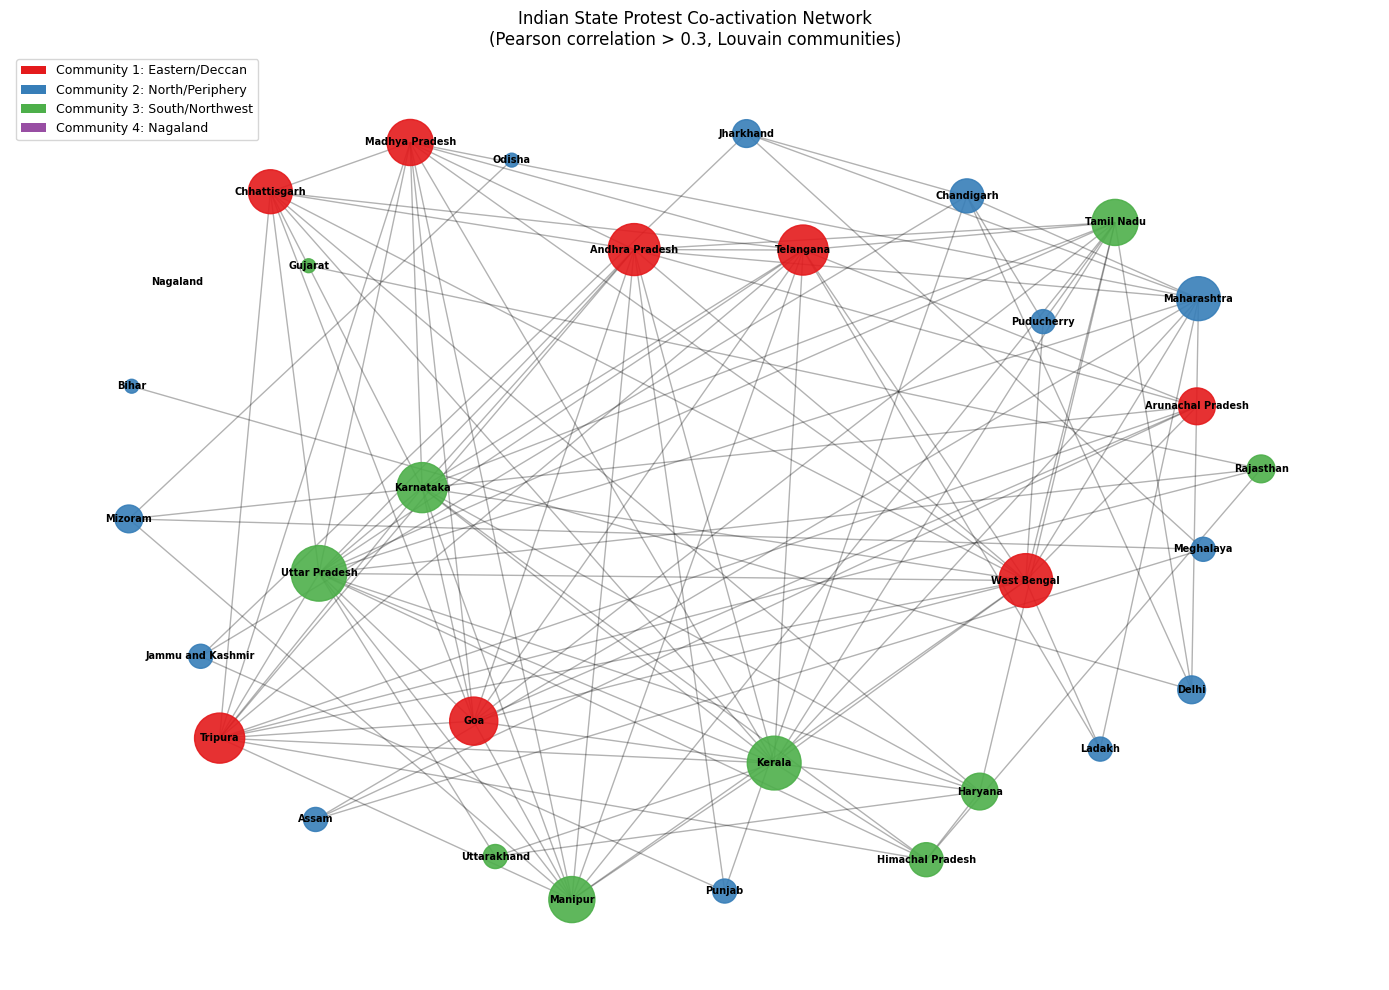

Saved as protest_network.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Use most stable partition
partition = community_louvain.best_partition(G2, weight='weight', random_state=42)

# Color nodes by community
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
node_colors = [colors[partition[node]] for node in G2.nodes()]

# Size nodes by degree
node_sizes = [G2.degree(node) * 100 for node in G2.nodes()]

# Layout
pos = nx.spring_layout(G2, weight='weight', seed=42, k=2)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G2, pos, node_color=node_colors, 
                        node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G2, pos, alpha=0.3, width=1)
nx.draw_networkx_labels(G2, pos, font_size=7, font_weight='bold')

# Legend
community_names = {
    0: 'Community 1: Eastern/Deccan',
    1: 'Community 2: North/Periphery', 
    2: 'Community 3: South/Northwest',
    3: 'Community 4: Nagaland'
}
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=community_names[i]) 
                   for i in range(4)]
plt.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.title('Indian State Protest Co-activation Network\n(Pearson correlation > 0.3, Louvain communities)', 
          fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('protest_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as protest_network.png")

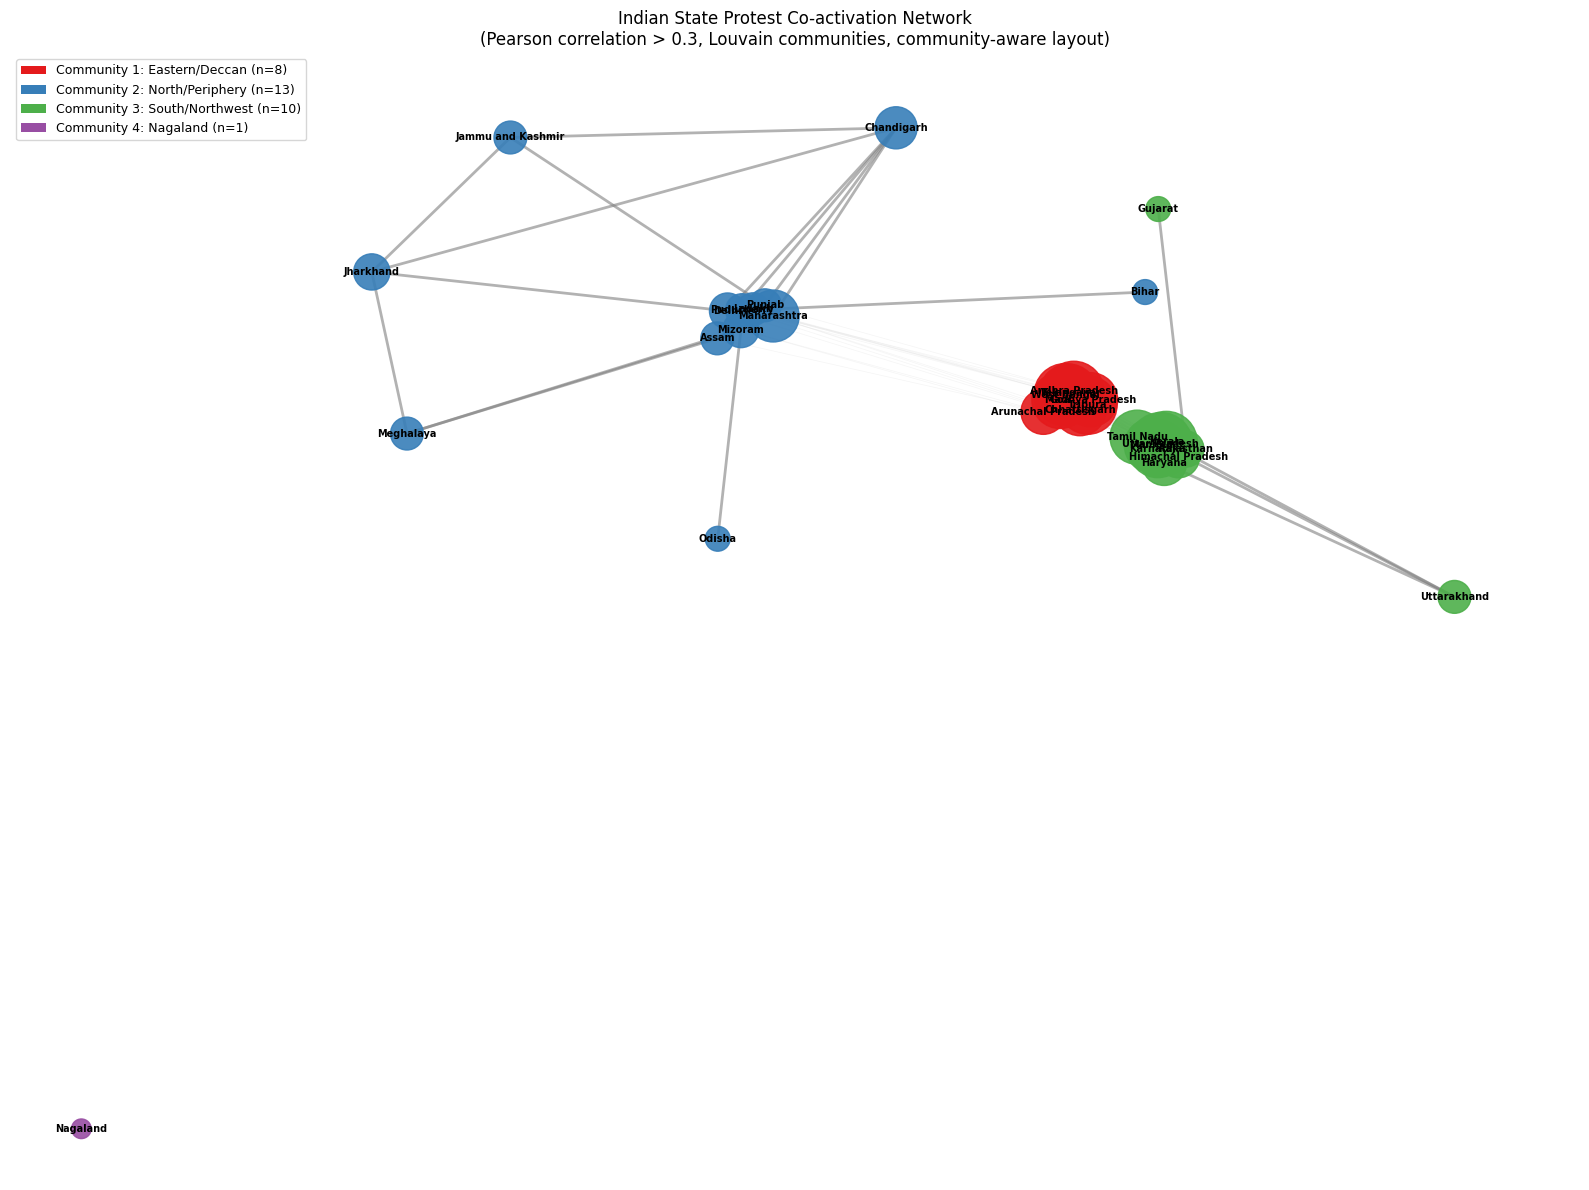

Saved as protest_network_v2.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Community-aware layout using kamada-kawai on a modified graph
# where intra-community edges are strengthened

# Create modified graph with boosted intra-community weights
G_layout = G2.copy()
for u, v, data in G_layout.edges(data=True):
    if partition[u] == partition[v]:
        # Boost intra-community edge weight for layout
        G_layout[u][v]['weight'] = data['weight'] * 3
    else:
        # Weaken inter-community edge weight
        G_layout[u][v]['weight'] = data['weight'] * 0.1

# Use kamada-kawai layout with modified weights
pos = nx.kamada_kawai_layout(G_layout, weight='weight')

# Further separate communities by shifting their centroids
community_groups = {}
for node, comm in partition.items():
    if comm not in community_groups:
        community_groups[comm] = []
    community_groups[comm].append(node)

# Shift each community centroid outward
separation = 1.5
centroids = {}
for comm, members in community_groups.items():
    cx = np.mean([pos[m][0] for m in members])
    cy = np.mean([pos[m][1] for m in members])
    centroids[comm] = (cx, cy)

# Overall centroid
overall_cx = np.mean([c[0] for c in centroids.values()])
overall_cy = np.mean([c[1] for c in centroids.values()])

# Push each community away from center
for comm, members in community_groups.items():
    cx, cy = centroids[comm]
    dx = cx - overall_cx
    dy = cy - overall_cy
    norm = max(np.sqrt(dx**2 + dy**2), 0.001)
    for m in members:
        pos[m] = (
            pos[m][0] + separation * dx/norm,
            pos[m][1] + separation * dy/norm
        )

# Draw
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
node_colors = [colors[partition[node]] for node in G2.nodes()]
node_sizes = [G2.degree(node) * 120 + 200 for node in G2.nodes()]

# Edge colors — intra vs inter community
edge_colors = []
edge_widths = []
for u, v in G2.edges():
    if partition[u] == partition[v]:
        edge_colors.append('gray')
        edge_widths.append(1.5)
    else:
        edge_colors.append('#dddddd')
        edge_widths.append(0.5)

plt.figure(figsize=(16, 12))

# Draw inter-community edges first (behind)
inter_edges = [(u,v) for u,v in G2.edges() if partition[u] != partition[v]]
intra_edges = [(u,v) for u,v in G2.edges() if partition[u] == partition[v]]

nx.draw_networkx_edges(G2, pos, edgelist=inter_edges, 
                        alpha=0.2, width=0.5, edge_color='#cccccc')
nx.draw_networkx_edges(G2, pos, edgelist=intra_edges,
                        alpha=0.6, width=2.0, edge_color='gray')
nx.draw_networkx_nodes(G2, pos, node_color=node_colors,
                        node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G2, pos, font_size=7, font_weight='bold')

# Legend
community_names = {
    0: 'Community 1: Eastern/Deccan (n=8)',
    1: 'Community 2: North/Periphery (n=13)',
    2: 'Community 3: South/Northwest (n=10)',
    3: 'Community 4: Nagaland (n=1)'
}
legend_elements = [mpatches.Patch(facecolor=colors[i], label=community_names[i])
                   for i in range(4)]
plt.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.title('Indian State Protest Co-activation Network\n'
          '(Pearson correlation > 0.3, Louvain communities, community-aware layout)',
          fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('protest_network_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as protest_network_v2.png")

In [31]:
# Does Punjab's Monday effect differ from national average?
india_dow = df_india[df_india['year'] < 2025].copy()
india_dow['dow'] = pd.to_datetime(india_dow['event_date']).dt.dayofweek
india_dow['dow_name'] = india_dow['dow'].map(
    {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
)

# National distribution
national_dow = india_dow.groupby('dow_name').size()
national_pct = (national_dow / national_dow.sum() * 100).round(1)

# Punjab distribution  
punjab_dow = india_dow[india_dow['admin1']=='Punjab'].groupby('dow_name').size()
punjab_pct = (punjab_dow / punjab_dow.sum() * 100).round(1)

# J&K distribution
jk_dow = india_dow[india_dow['admin1']=='Jammu and Kashmir'].groupby('dow_name').size()
jk_pct = (jk_dow / jk_dow.sum() * 100).round(1)

# Tamil Nadu for comparison
tn_dow = india_dow[india_dow['admin1']=='Tamil Nadu'].groupby('dow_name').size()
tn_pct = (tn_dow / tn_dow.sum() * 100).round(1)

comparison = pd.DataFrame({
    'National': national_pct,
    'Punjab': punjab_pct,
    'J&K': jk_pct,
    'Tamil Nadu': tn_pct
}).reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

print("=== Day of week distribution (%) ===")
print(comparison)

# Also check sub_event_type by day
print("\n=== Sub-event type by day (national) ===")
dow_subtype = india_dow.groupby(['dow_name', 'sub_event_type']).size().unstack(fill_value=0)
dow_subtype_pct = dow_subtype.div(dow_subtype.sum(axis=1), axis=0).round(3) * 100
print(dow_subtype_pct.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))

=== Day of week distribution (%) ===
          National  Punjab   J&K  Tamil Nadu
dow_name                                    
Mon           19.2    19.6  17.9        22.4
Tue           15.4    15.0  15.3        20.0
Wed           14.8    14.1  14.7        15.0
Thu           14.4    14.3  14.3        12.5
Fri           15.1    15.1  16.2        13.0
Sat           11.6    11.0  12.9        10.7
Sun            9.5    10.9   8.8         6.4

=== Sub-event type by day (national) ===
sub_event_type  Excessive force against protesters  Peaceful protest  \
dow_name                                                               
Mon                                            0.1              94.0   
Tue                                            0.1              93.9   
Wed                                            0.1              94.0   
Thu                                            0.2              94.0   
Fri                                            0.2              94.1   
Sat         

In [32]:
# Basic text exploration
import re

notes = df_india[df_india['year'] < 2025]['notes'].dropna()

print(f"Total notes: {len(notes)}")
print(f"Missing notes: {df_india['notes'].isna().sum()}")

# Average length
lengths = notes.str.len()
print(f"\nNote length stats:")
print(lengths.describe().round(0))

# Most common words (crude, no stopwords yet)
from collections import Counter

# Simple word frequency
all_words = ' '.join(notes.str.lower().values).split()
word_freq = Counter(all_words)

print("\n=== Top 50 most common words ===")
print(word_freq.most_common(50))

Total notes: 132354
Missing notes: 0

Note length stats:
count    132354.0
mean        253.0
std         102.0
min          31.0
25%         182.0
50%         232.0
75%         301.0
max        1980.0
Name: notes, dtype: float64

=== Top 50 most common words ===
[('the', 354010), ('of', 222503), ('in', 184443), ('a', 171154), ('on', 145078), ('and', 122310), ('protest', 91948), ('against', 75843), ('to', 75742), ('staged', 75685), ('members', 50850), ('city', 50723), ('at', 49608), ('for', 39809), ('by', 35513), ('demanding', 32506), ('held', 30683), ('district,', 22812), ('government', 22189), ('district', 20842), ('2024,', 20647), ('state', 20418), ('over', 20048), ('their', 19123), ('town', 18352), ('2023,', 17273), ('from', 17086), ('police', 16549), ('march', 16385), ('as', 16244), ('2019,', 15873), ('an', 14936), ('farmers', 14767), ('2021,', 14756), ('with', 14385), ('2022,', 14235), ('including', 14068), ('2020,', 13794), ('bjp', 13254), ('protests', 13047), ('protesters', 1244

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
import numpy as np

# Sample for speed — use 30k notes
sample_notes = notes.sample(30000, random_state=42)

# TF-IDF with stopwords
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words='english',
    min_df=10,
    max_df=0.95,
    ngram_range=(1,2)  # unigrams and bigrams
)

tfidf_matrix = vectorizer.fit_transform(sample_notes)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Top terms overall
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[-50:][::-1]

print("\n=== Top 50 meaningful terms ===")
print([feature_names[i] for i in top_indices])

# LDA topic modeling
print("\nFitting LDA with 8 topics...")
lda = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=20
)
lda.fit(tfidf_matrix)

print("\n=== LDA Topics ===")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-12:][::-1]]
    print(f"\nTopic {topic_idx+1}: {top_words}")

TF-IDF matrix shape: (30000, 2000)

=== Top 50 meaningful terms ===
['protest', 'staged', 'city', 'members', 'staged protest', 'district', 'held', 'demanding', 'government', 'state', 'held protest', 'town', '2019', 'farmers', 'police', 'bjp', '2021', '2024', 'march', 'punjab', '2023', 'students', '2020', '2022', 'delhi', 'village', 'protests', 'workers', 'august', '2018', 'september', 'pradesh', 'december', 'protesters', 'including', 'july', 'assam', 'led', 'october', 'june', 'union', 'office', 'february', 'november', 'demonstration', 'congress', 'protested', 'road', 'january', 'employees']

Fitting LDA with 8 topics...

=== LDA Topics ===

Topic 1: ['assam', 'district', 'staged', 'congress', 'district assam', 'prices', 'bengaluru', 'protest', 'members', 'fuel', 'demonstration', 'students']

Topic 2: ['students', 'university', '2019', 'college', 'school', 'hyderabad', 'protest', 'medical', '2019 caa', 'act 2019', 'city', 'amendment act']

Topic 3: ['police', 'protest', 'members', 'prad

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

custom_stops = [
    'staged', 'held', 'protest', 'protests', 'protesters', 'protested',
    'demonstration', 'members', 'city', 'district', 'town', 'village',
    'state', 'including', 'january', 'february', 'march', 'april', 'may',
    'june', 'july', 'august', 'september', 'october', 'november', 'december',
    '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
    'pradesh', 'india', 'led', 'office', 'road', 'area', 'local', 'also',
    'police', 'demanding', 'demand', 'demands', 'government', 'against',
    'under', 'banner', 'organisation', 'organization', 'held protest',
    'staged protest', 'took', 'also', 'rally'
]

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stops = list(ENGLISH_STOP_WORDS) + custom_stops

# Refit on full dataset this time
print("Fitting vectorizer on full dataset...")
vectorizer2 = TfidfVectorizer(
    max_features=3000,
    stop_words=all_stops,
    min_df=10,
    max_df=0.90,
    ngram_range=(1,2)
)

# Use full india dataset
full_notes = df_india[df_india['year'] < 2025]['notes'].fillna('')
tfidf_full = vectorizer2.fit_transform(full_notes)
print(f"Full TF-IDF matrix: {tfidf_full.shape}")

# Refit LDA with 8 topics
print("Fitting LDA on full dataset (may take 2-3 mins)...")
lda2 = LatentDirichletAllocation(
    n_components=8,
    random_state=42,
    max_iter=30,
    n_jobs=-1
)
lda2.fit(tfidf_full)

feature_names2 = vectorizer2.get_feature_names_out()
print("\n=== Refined LDA Topics ===")
for topic_idx, topic in enumerate(lda2.components_):
    top_words = [feature_names2[i] for i in topic.argsort()[-15:][::-1]]
    print(f"\nTopic {topic_idx+1}: {top_words}")

Fitting vectorizer on full dataset...
Full TF-IDF matrix: (132354, 3000)
Fitting LDA on full dataset (may take 2-3 mins)...

=== Refined LDA Topics ===

Topic 1: ['assam', 'students', 'college', 'school', 'medical', 'students union', 'doctors', 'university', 'union', 'aasu', 'citizenship', 'scheduled', 'amendment', 'citizenship amendment', 'doctor']

Topic 2: ['farmers', 'punjab', 'manipur', 'bku', 'meitei', 'haryana', 'imphal', 'water', 'skm', 'farm', 'supply', 'kisan', 'violence', 'laws', 'farm laws']

Topic 3: ['tamil', 'nadu', 'tamil nadu', 'tn', 'kerala', 'chennai', 'dmk', 'cpi', 'coimbatore', 'madurai', 'thiruvananthapuram', 'union', 'salem', 'trade', 'indian']

Topic 4: ['tripura', 'west', 'bengal', 'west bengal', 'coronavirus', 'wb', 'citizenship', 'prices', 'citizenship amendment', 'amendment', 'bjp', 'pandemic', 'coronavirus pandemic', 'fuel', 'caa']

Topic 5: ['employees', 'teachers', 'jammu', 'pay', 'goa', 'visakhapatnam', 'pension', 'department', 'association', 'wages', 'b

In [35]:
# Assign dominant topic to every event
print("Assigning topics to all events...")
topic_distributions = lda2.transform(tfidf_full)

# Dominant topic per event
df_india_clean = df_india[df_india['year'] < 2025].copy()
df_india_clean['dominant_topic'] = topic_distributions.argmax(axis=1)
df_india_clean['topic_confidence'] = topic_distributions.max(axis=1)

# Topic labels
topic_labels = {
    0: 'Student/CAA',
    1: 'Farmer/Ethnic',
    2: 'South Labor',
    3: 'WB/Northeast/CAA',
    4: 'Public Sector',
    5: 'Urban Civic',
    6: 'Communal/Local',
    7: 'Party Political'
}
df_india_clean['topic_label'] = df_india_clean['dominant_topic'].map(topic_labels)

# Distribution
print("\n=== Topic distribution ===")
print(df_india_clean['topic_label'].value_counts())

# Confidence distribution
print("\n=== Topic confidence stats ===")
print(df_india_clean['topic_confidence'].describe().round(3))

# Low confidence events
print(f"\nEvents with confidence < 0.3: {(df_india_clean['topic_confidence'] < 0.3).sum()}")
print(f"Events with confidence > 0.5: {(df_india_clean['topic_confidence'] > 0.5).sum()}")

Assigning topics to all events...

=== Topic distribution ===
topic_label
Communal/Local      25326
Urban Civic         19812
Party Political     15878
Public Sector       15249
Student/CAA         14767
Farmer/Ethnic       14484
South Labor         14044
WB/Northeast/CAA    12794
Name: count, dtype: int64

=== Topic confidence stats ===
count    132354.000
mean          0.665
std           0.151
min           0.125
25%           0.526
50%           0.706
75%           0.801
max           0.920
Name: topic_confidence, dtype: float64

Events with confidence < 0.3: 107
Events with confidence > 0.5: 105555


In [36]:
# Question 1: Does topic explain the Monday effect?
df_india_clean['dow'] = pd.to_datetime(df_india_clean['event_date']).dt.dayofweek
df_india_clean['dow_name'] = df_india_clean['dow'].map(
    {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
)

# Monday share by topic
print("=== Monday share by topic ===")
monday_by_topic = df_india_clean.groupby('topic_label').apply(
    lambda x: (x['dow_name'] == 'Mon').sum() / len(x) * 100
).round(1).sort_values(ascending=False)
print(monday_by_topic)

# Question 2: Does topic explain Punjab's uniqueness?
print("\n=== Topic distribution by state (top 8 states) ===")
top_states = ['Punjab', 'Jammu and Kashmir', 'Tamil Nadu', 
              'Assam', 'Uttar Pradesh', 'Karnataka', 
              'West Bengal', 'Haryana']

state_topic = df_india_clean[df_india_clean['admin1'].isin(top_states)].groupby(
    ['admin1', 'topic_label']
).size().unstack(fill_value=0)

state_topic_pct = state_topic.div(state_topic.sum(axis=1), axis=0).round(3) * 100
print(state_topic_pct)

=== Monday share by topic ===
topic_label
South Labor         22.7
WB/Northeast/CAA    20.6
Farmer/Ethnic       20.0
Student/CAA         20.0
Urban Civic         19.9
Public Sector       19.2
Communal/Local      16.6
Party Political     16.5
dtype: float64

=== Topic distribution by state (top 8 states) ===
topic_label        Communal/Local  Farmer/Ethnic  Party Political  \
admin1                                                              
Assam                         5.4            0.8              3.1   
Haryana                      14.9           30.5             10.5   
Jammu and Kashmir            43.4            5.8              2.5   
Karnataka                    10.5            2.7             14.4   
Punjab                       21.8           35.0              5.9   
Tamil Nadu                    6.4            1.7              4.3   
Uttar Pradesh                47.6            6.7             13.5   
West Bengal                  10.6            1.7              9.4   



C:\Users\dell\AppData\Local\Temp\ipykernel_28048\288473703.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monday_by_topic = df_india_clean.groupby('topic_label').apply(


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Task: Predict whether a protest happens on Monday or not
# Using: state, topic, year, sub_event_type, source_scale

df_model = df_india_clean.copy()

# Binary target
df_model['is_monday'] = (df_model['dow'] == 0).astype(int)

# Features
le_state = LabelEncoder()
le_source = LabelEncoder()
le_subtype = LabelEncoder()

df_model['state_enc'] = le_state.fit_transform(df_model['admin1'])
df_model['source_enc'] = le_source.fit_transform(df_model['source_scale'].fillna('Unknown'))
df_model['subtype_enc'] = le_subtype.fit_transform(df_model['sub_event_type'])

features = ['state_enc', 'dominant_topic', 'topic_confidence', 
            'year', 'source_enc', 'subtype_enc']

X = df_model[features]
y = df_model['is_monday']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Monday share in full data: {y.mean():.3f}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

# Feature importance
print("\n=== Feature Importance ===")
for feat, imp in sorted(zip(features, rf.feature_importances_), 
                         key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

Train: 105883, Test: 26471
Monday share in full data: 0.192

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      1.00      0.89     21397
           1       0.00      0.00      0.00      5074

    accuracy                           0.81     26471
   macro avg       0.40      0.50      0.45     26471
weighted avg       0.65      0.81      0.72     26471



C:\Users\dell\anaconda3\envs\datasci\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\anaconda3\envs\datasci\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dell\anaconda3\envs\datasci\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     21397
           1       0.36      0.29      0.32      5074

    accuracy                           0.77     26471
   macro avg       0.60      0.58      0.59     26471
weighted avg       0.75      0.77      0.76     26471


=== Feature Importance ===
topic_confidence: 0.770
state_enc: 0.103
year: 0.059
dominant_topic: 0.039
source_enc: 0.020
subtype_enc: 0.010


In [38]:
# Better target: weekday vs weekend
df_model['is_weekend'] = (df_model['dow'] >= 5).astype(int)
print(f"Weekend share: {df_model['is_weekend'].mean():.3f}")

# Remove topic_confidence, add month as feature
features_v2 = ['state_enc', 'dominant_topic', 
                'year', 'source_enc', 'subtype_enc',
                'dow']  # remove dow for final model, just checking now

features_v2 = ['state_enc', 'dominant_topic', 
                'year', 'source_enc', 'subtype_enc']

X2 = df_model[features_v2]
y2 = df_model['is_weekend']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Logistic Regression with class weight
lr2 = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
lr2.fit(X_train2, y_train2)
y_pred_lr2 = lr2.predict(X_test2)

print("\n=== Logistic Regression (balanced) ===")
print(classification_report(y_test2, y_pred_lr2))

# Random Forest with class weight
rf2 = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced'
)
rf2.fit(X_train2, y_train2)
y_pred_rf2 = rf2.predict(X_test2)

print("\n=== Random Forest (balanced) ===")
print(classification_report(y_test2, y_pred_rf2))

print("\n=== Feature Importance ===")
for feat, imp in sorted(zip(features_v2, rf2.feature_importances_), 
                         key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

Weekend share: 0.211

=== Logistic Regression (balanced) ===
              precision    recall  f1-score   support

           0       0.80      0.47      0.59     20878
           1       0.22      0.57      0.32      5593

    accuracy                           0.49     26471
   macro avg       0.51      0.52      0.46     26471
weighted avg       0.68      0.49      0.54     26471


=== Random Forest (balanced) ===
              precision    recall  f1-score   support

           0       0.84      0.62      0.71     20878
           1       0.29      0.57      0.38      5593

    accuracy                           0.61     26471
   macro avg       0.56      0.59      0.55     26471
weighted avg       0.73      0.61      0.64     26471


=== Feature Importance ===
state_enc: 0.420
year: 0.240
dominant_topic: 0.172
source_enc: 0.125
subtype_enc: 0.043


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Target: dominant topic (8 classes)
# Only use high confidence assignments to keep labels clean
df_model2 = df_india_clean[df_india_clean['topic_confidence'] > 0.5].copy()
print(f"High confidence events: {len(df_model2)}")
print(f"Random baseline accuracy: {1/8:.3f}")

# Features — no text, no topic confidence
le_state = LabelEncoder()
le_source = LabelEncoder()
le_subtype = LabelEncoder()

df_model2['state_enc'] = le_state.fit_transform(df_model2['admin1'])
df_model2['source_enc'] = le_source.fit_transform(df_model2['source_scale'].fillna('Unknown'))
df_model2['subtype_enc'] = le_subtype.fit_transform(df_model2['sub_event_type'])
df_model2['month'] = pd.to_datetime(df_model2['event_date']).dt.month
df_model2['dow'] = pd.to_datetime(df_model2['event_date']).dt.dayofweek

features = ['state_enc', 'year', 'month', 'dow', 'source_enc', 'subtype_enc']
target = 'dominant_topic'

X = df_model2[features]
y = df_model2[target]

# Temporal split — train on pre-2023, test on 2023-2024
X_train = df_model2[df_model2['year'] < 2023][features]
y_train = df_model2[df_model2['year'] < 2023][target]
X_test = df_model2[df_model2['year'] >= 2023][features]
y_test = df_model2[df_model2['year'] >= 2023][target]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution:\n{y.value_counts()}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print(f"Accuracy: {(y_pred_lr == y_test).mean():.3f}")
print(classification_report(y_test, y_pred_lr, 
      target_names=list(topic_labels.values())))

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    n_jobs=-1,
    class_weight='balanced',
    max_depth=15
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"Accuracy: {(y_pred_rf == y_test).mean():.3f}")
print(classification_report(y_test, y_pred_rf,
      target_names=list(topic_labels.values())))

# Feature importance
print("\n=== Feature Importance ===")
for feat, imp in sorted(zip(features, rf.feature_importances_),
                         key=lambda x: -x[1]):
    print(f"{feat}: {imp:.3f}")

High confidence events: 105555
Random baseline accuracy: 0.125
Train: 73710, Test: 31845
Class distribution:
dominant_topic
6    20796
5    15884
7    12022
4    11976
1    11896
2    11501
0    11493
3     9987
Name: count, dtype: int64


C:\Users\dell\anaconda3\envs\datasci\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
Accuracy: 0.214
                  precision    recall  f1-score   support

     Student/CAA       0.16      0.31      0.21      2707
   Farmer/Ethnic       0.54      0.19      0.29      4953
     South Labor       0.34      0.54      0.42      4522
WB/Northeast/CAA       0.08      0.34      0.13      1857
   Public Sector       0.13      0.11      0.12      2850
     Urban Civic       0.04      0.00      0.00      4643
  Communal/Local       0.25      0.01      0.01      6305
 Party Political       0.22      0.40      0.29      4008

        accuracy                           0.21     31845
       macro avg       0.22      0.24      0.18     31845
    weighted avg       0.25      0.21      0.18     31845


=== Random Forest ===
Accuracy: 0.458
                  precision    recall  f1-score   support

     Student/CAA       0.39      0.29      0.33      2707
   Farmer/Ethnic       0.59      0.67      0.63      4953
     South Labor       0.76      0.74     

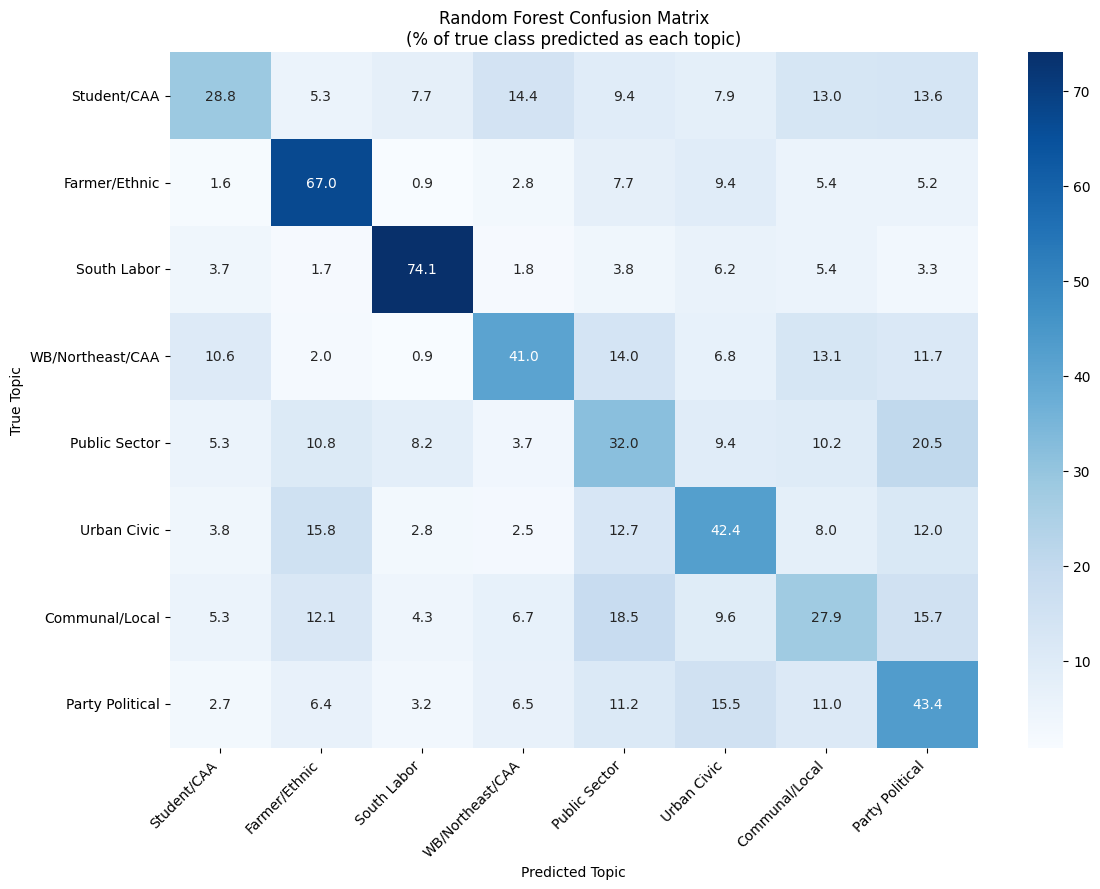

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = list(topic_labels.values())

plt.figure(figsize=(12, 9))
sns.heatmap(cm_pct, 
            annot=True, 
            fmt='.1f',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title('Random Forest Confusion Matrix\n(% of true class predicted as each topic)', 
          fontsize=12)
plt.ylabel('True Topic')
plt.xlabel('Predicted Topic')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()